In [1]:
import pandas as pd

In [2]:
# Open the aggregated crime data
import io
from google.colab import files
uploaded = files.upload()
df1 = pd.read_csv(io.BytesIO(uploaded['grouped_counts_all_crimes_with_zeros_short - Copy.csv']))
df1.shape

Saving grouped_counts_all_crimes_with_zeros_short - Copy.csv to grouped_counts_all_crimes_with_zeros_short - Copy.csv


(32864, 3)

In [3]:
df1.head()

,HOOD_158,WEEK_SEQ,Crime_counts
0,1,1,19
1,1,2,11
2,1,3,12
3,1,4,20
4,1,5,12


In [4]:
# Open the neighbourhood-profiles prepared data
uploaded = files.upload()
df2 = pd.read_csv(io.BytesIO(uploaded['neighbourhood_profiles_prepared_data - Copy.csv']))
df2 = df2.rename(columns={'Unnamed: 0': 'HOOD_NAME'})
df2.columns

Saving neighbourhood_profiles_prepared_data - Copy.csv to neighbourhood_profiles_prepared_data - Copy.csv


Index(['HOOD_NAME', 'POP_TOTAL', 'HOOD_NUMBER', 'POP_AGE_GROUP_0_14',
       'POP_AGE_GROUP_15_64', 'POP_AGE_GROUP_65_', 'POP_AVG_AGE',
       'POP_MED_AGE', 'MARRIED_%', 'POP_GOV_SUPP_SHARE', 'AVG_HHOLD_SIZE',
       'AVG_TOT_HHOLD_INC', 'OWNER_HHOLDS_%', 'DW_W_CONDO_STATUS_%',
       'HHOLDS_UNSUIT_HOU_%', 'DW_REQ_MAJ_REPAIR_%', 'SCTI_RAT_GT30_%',
       'HHOLD_OWN_MRTG_HOLD_%', 'HHOLD_OWN_SCTI_GT30_%', 'AVG_DW_VAL',
       'HHOLDS_IN_SUBS_HOUS_%', 'HHOLDS_OWN_AVG_MNTH_COST',
       'HHOLDS_RENT_AVG_MNTH_COST', 'AVG_FAM_SIZE', 'ONE_PAR_FAM_%',
       'AVG_NUM_CH_PER_FAM', 'HHOLD_FIRST_LANG_EN_%', 'HHOLD_FIRST_LANG_FR_%',
       'HHOLD_FIRST_LANG_ENFR_%', 'HHOLD_FIRST_LANG_OTH_%', 'POP_NONCITIZ_%',
       'POP_NON_IMMIGR_%', 'POP_IMMIGR_%', 'POP_TEMP_RES_%', 'PARTICIP_RATE',
       'UNEMPLOY_RATE', 'POP_NO_EDUC_%', 'POP_HIGH_SCH_EDUC_%',
       'POP_POSTSEC_EDUC_%', 'COMMUTE_CAR_%', 'COMMUTE_TRANSIT_%',
       'COMMUTE_WALK_%', 'COMMUTE_CYCLE_%', 'COMMUTE_OTHER_%',
       'COMMUTE_LT_

In [5]:
# Merge the crime indicators and the neighbourhood profiles dataset on Hood_id column. Calculate crime_counts per 10k of population.
df_all_crimes_enriched = pd.merge(df1, df2, how='left', left_on = 'HOOD_158', right_on = 'HOOD_NUMBER' )
df_all_crimes_enriched['Crime_counts'] = (df_all_crimes_enriched['Crime_counts'] / df_all_crimes_enriched['POP_TOTAL']) * 10000
df_all_crimes_enriched.head(5)

,HOOD_158,WEEK_SEQ,Crime_counts,HOOD_NAME,POP_TOTAL,HOOD_NUMBER,POP_AGE_GROUP_0_14,POP_AGE_GROUP_15_64,POP_AGE_GROUP_65_,POP_AVG_AGE,...,COMMUTE_OTHER_%,COMMUTE_LT_30_MIN_%,COMMUTE_30_59_MIN_%,COMMUTE_GT_59_MIN_%,COMMUTE_START_5_6_AM_%,COMMUTE_START_6_7_AM_%,COMMUTE_START_7_8_AM_%,COMMUTE_START_8_9_AM_%,COMMUTE_START_9_AM_noon_%,COMMUTE_START_noon_5_AM_%
0,1,1,5.705706,West Humber-Clairville,33300,1,12.9,71.0,16.1,40.5,...,0.016641,0.518189,0.350232,0.131192,0.075851,0.189241,0.20356,0.175697,0.12887,0.227167
1,1,2,3.303303,West Humber-Clairville,33300,1,12.9,71.0,16.1,40.5,...,0.016641,0.518189,0.350232,0.131192,0.075851,0.189241,0.20356,0.175697,0.12887,0.227167
2,1,3,3.603604,West Humber-Clairville,33300,1,12.9,71.0,16.1,40.5,...,0.016641,0.518189,0.350232,0.131192,0.075851,0.189241,0.20356,0.175697,0.12887,0.227167
3,1,4,6.006006,West Humber-Clairville,33300,1,12.9,71.0,16.1,40.5,...,0.016641,0.518189,0.350232,0.131192,0.075851,0.189241,0.20356,0.175697,0.12887,0.227167
4,1,5,3.603604,West Humber-Clairville,33300,1,12.9,71.0,16.1,40.5,...,0.016641,0.518189,0.350232,0.131192,0.075851,0.189241,0.20356,0.175697,0.12887,0.227167


In [6]:
df_all_crimes_enriched.shape

(32864, 56)

In [7]:
df_all_crimes_enriched.tail()

,HOOD_158,WEEK_SEQ,Crime_counts,HOOD_NAME,POP_TOTAL,HOOD_NUMBER,POP_AGE_GROUP_0_14,POP_AGE_GROUP_15_64,POP_AGE_GROUP_65_,POP_AVG_AGE,...,COMMUTE_OTHER_%,COMMUTE_LT_30_MIN_%,COMMUTE_30_59_MIN_%,COMMUTE_GT_59_MIN_%,COMMUTE_START_5_6_AM_%,COMMUTE_START_6_7_AM_%,COMMUTE_START_7_8_AM_%,COMMUTE_START_8_9_AM_%,COMMUTE_START_9_AM_noon_%,COMMUTE_START_noon_5_AM_%
32859,174,204,2.639103,South Eglinton-Davisville,22735,174,9.6,77.0,13.4,40.1,...,0.035508,0.468208,0.440958,0.090834,0.028902,0.099092,0.224608,0.297275,0.229562,0.120562
32860,174,205,2.199252,South Eglinton-Davisville,22735,174,9.6,77.0,13.4,40.1,...,0.035508,0.468208,0.440958,0.090834,0.028902,0.099092,0.224608,0.297275,0.229562,0.120562
32861,174,206,2.199252,South Eglinton-Davisville,22735,174,9.6,77.0,13.4,40.1,...,0.035508,0.468208,0.440958,0.090834,0.028902,0.099092,0.224608,0.297275,0.229562,0.120562
32862,174,207,0.879701,South Eglinton-Davisville,22735,174,9.6,77.0,13.4,40.1,...,0.035508,0.468208,0.440958,0.090834,0.028902,0.099092,0.224608,0.297275,0.229562,0.120562
32863,174,208,0.879701,South Eglinton-Davisville,22735,174,9.6,77.0,13.4,40.1,...,0.035508,0.468208,0.440958,0.090834,0.028902,0.099092,0.224608,0.297275,0.229562,0.120562


In [8]:
#check how many features have missing data
sample_incomplete_rows = df_all_crimes_enriched[df_all_crimes_enriched.isnull().any(axis=1)].head()
sample_incomplete_rows

,HOOD_158,WEEK_SEQ,Crime_counts,HOOD_NAME,POP_TOTAL,HOOD_NUMBER,POP_AGE_GROUP_0_14,POP_AGE_GROUP_15_64,POP_AGE_GROUP_65_,POP_AVG_AGE,...,COMMUTE_OTHER_%,COMMUTE_LT_30_MIN_%,COMMUTE_30_59_MIN_%,COMMUTE_GT_59_MIN_%,COMMUTE_START_5_6_AM_%,COMMUTE_START_6_7_AM_%,COMMUTE_START_7_8_AM_%,COMMUTE_START_8_9_AM_%,COMMUTE_START_9_AM_noon_%,COMMUTE_START_noon_5_AM_%


In [9]:
# Separate Exploratory (X) from target (y)
df_all_crimes_enriched_features = df_all_crimes_enriched.drop(["Crime_counts", "POP_TOTAL", 'HOOD_NAME', 'HOOD_158', 'WEEK_SEQ', 'HOOD_NUMBER'], axis=1) # drop labels for training set
df_all_crimes_enriched_labels = df_all_crimes_enriched["Crime_counts"].copy() #get a copy of the label
df_all_crimes_enriched_labels.tail()

,Crime_counts
32859,2.639103
32860,2.199252
32861,2.199252
32862,0.879701
32863,0.879701


In [10]:
# Average number of crimes per week
df_all_crimes_enriched['Crime_counts'].mean()

np.float64(2.9350127452386228)

In [11]:
#Split the dataset into training and test subsets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_all_crimes_enriched_features, df_all_crimes_enriched_labels, train_size = 0.8, random_state=42)

In [12]:
X_train

,POP_AGE_GROUP_0_14,POP_AGE_GROUP_15_64,POP_AGE_GROUP_65_,POP_AVG_AGE,POP_MED_AGE,MARRIED_%,POP_GOV_SUPP_SHARE,AVG_HHOLD_SIZE,AVG_TOT_HHOLD_INC,OWNER_HHOLDS_%,...,COMMUTE_OTHER_%,COMMUTE_LT_30_MIN_%,COMMUTE_30_59_MIN_%,COMMUTE_GT_59_MIN_%,COMMUTE_START_5_6_AM_%,COMMUTE_START_6_7_AM_%,COMMUTE_START_7_8_AM_%,COMMUTE_START_8_9_AM_%,COMMUTE_START_9_AM_noon_%,COMMUTE_START_noon_5_AM_%
32417,11.0,73.0,16.0,41.9,39.2,0.497957,16.8,2.3,111500,0.546139,...,0.030043,0.490701,0.429185,0.081545,0.052933,0.131617,0.197425,0.236052,0.221745,0.163090
8979,11.9,59.3,28.7,47.5,49.6,0.556597,20.5,2.6,105900,0.724354,...,0.027435,0.445816,0.403292,0.149520,0.037037,0.142661,0.185185,0.262003,0.238683,0.133059
9403,10.2,69.4,20.3,43.9,42.4,0.536674,17.6,2.5,109400,0.620438,...,0.025000,0.450000,0.428571,0.123810,0.029762,0.083333,0.182143,0.269048,0.282143,0.154762
13137,16.9,69.2,14.0,39.9,40.4,0.503620,15.5,2.4,120500,0.541935,...,0.030899,0.494382,0.424157,0.078652,0.044944,0.095506,0.261236,0.238764,0.205056,0.154494
8895,14.3,67.2,18.5,42.0,41.2,0.536282,21.4,2.6,99100,0.506595,...,0.027152,0.424503,0.427152,0.147020,0.045695,0.126490,0.207285,0.232450,0.215894,0.172185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16850,14.7,71.4,13.9,40.3,39.2,0.500549,23.4,2.6,94700,0.593564,...,0.023006,0.346626,0.493865,0.157975,0.090491,0.196319,0.217791,0.196319,0.147239,0.151840
6265,14.3,68.0,17.7,42.3,42.4,0.520658,18.3,2.6,116800,0.540808,...,0.051657,0.461014,0.418129,0.119883,0.046784,0.124756,0.224172,0.234893,0.186160,0.182261
11284,16.3,67.5,16.1,41.5,41.6,0.560000,14.6,2.3,116500,0.662722,...,0.028708,0.466507,0.430622,0.100478,0.038278,0.148325,0.248804,0.246411,0.167464,0.148325
860,17.2,67.9,14.9,39.6,38.4,0.438993,29.4,2.9,94600,0.550861,...,0.028668,0.527825,0.350759,0.121417,0.084317,0.197302,0.198988,0.172007,0.119730,0.227656


In [13]:
# Train random forest regressor on full-feature dataset and determine feature importances
from sklearn.ensemble import RandomForestRegressor
rnd_reg = RandomForestRegressor(n_estimators=20, random_state=42)
rnd_reg.fit(X_train, y_train)
for score, name in zip(rnd_reg.feature_importances_, df_all_crimes_enriched_features.columns):
  print(round(score, 4), '|', name)

0.0104 | POP_AGE_GROUP_0_14
0.0516 | POP_AGE_GROUP_15_64
0.0103 | POP_AGE_GROUP_65_
0.0075 | POP_AVG_AGE
0.0065 | POP_MED_AGE
0.0288 | MARRIED_%
0.0075 | POP_GOV_SUPP_SHARE
0.0019 | AVG_HHOLD_SIZE
0.0033 | AVG_TOT_HHOLD_INC
0.0173 | OWNER_HHOLDS_%
0.0034 | DW_W_CONDO_STATUS_%
0.0038 | HHOLDS_UNSUIT_HOU_%
0.0082 | DW_REQ_MAJ_REPAIR_%
0.0037 | SCTI_RAT_GT30_%
0.0107 | HHOLD_OWN_MRTG_HOLD_%
0.0142 | HHOLD_OWN_SCTI_GT30_%
0.0042 | AVG_DW_VAL
0.0399 | HHOLDS_IN_SUBS_HOUS_%
0.0018 | HHOLDS_OWN_AVG_MNTH_COST
0.01 | HHOLDS_RENT_AVG_MNTH_COST
0.0013 | AVG_FAM_SIZE
0.0059 | ONE_PAR_FAM_%
0.0013 | AVG_NUM_CH_PER_FAM
0.0177 | HHOLD_FIRST_LANG_EN_%
0.0078 | HHOLD_FIRST_LANG_FR_%
0.0379 | HHOLD_FIRST_LANG_ENFR_%
0.103 | HHOLD_FIRST_LANG_OTH_%
0.0024 | POP_NONCITIZ_%
0.0047 | POP_NON_IMMIGR_%
0.0045 | POP_IMMIGR_%
0.0402 | POP_TEMP_RES_%
0.0108 | PARTICIP_RATE
0.0026 | UNEMPLOY_RATE
0.0064 | POP_NO_EDUC_%
0.0214 | POP_HIGH_SCH_EDUC_%
0.0076 | POP_POSTSEC_EDUC_%
0.08 | COMMUTE_CAR_%
0.0043 | COMMUTE_T

In [14]:
#Determine RMSE scores for applying RendomForestRegressor on train and test sets
from sklearn.metrics import mean_squared_error, root_mean_squared_error
y_pred_rf = rnd_reg.predict(X_test)
rmse_scores = pd.DataFrame({'Model': ['RandomForest Regressor - full feature'], 'RMSE Train': [root_mean_squared_error(y_train, rnd_reg.predict(X_train))], 'RMSE Test': [root_mean_squared_error(y_test, y_pred_rf)]})
print("RMSE of RandomForest regressor on train dataset is:",root_mean_squared_error(y_train, rnd_reg.predict(X_train)))
print("RMSE of RandomForest regressor on test dataset is:",root_mean_squared_error(y_test, y_pred_rf))

RMSE of RandomForest regressor on train dataset is: 1.7867480625223142
RMSE of RandomForest regressor on test dataset is: 1.7896985195146664


In [15]:
# Select important features only
df_all_crimes_reduced_features = df_all_crimes_enriched[['COMMUTE_WALK_%','HHOLD_FIRST_LANG_OTH_%','COMMUTE_CAR_%','POP_AGE_GROUP_15_64','POP_TEMP_RES_%','COMMUTE_START_7_8_AM_%','COMMUTE_START_5_6_AM_%','HHOLD_FIRST_LANG_ENFR_%']]
df_all_crimes_reduced_features

,COMMUTE_WALK_%,HHOLD_FIRST_LANG_OTH_%,COMMUTE_CAR_%,POP_AGE_GROUP_15_64,POP_TEMP_RES_%,COMMUTE_START_7_8_AM_%,COMMUTE_START_5_6_AM_%,HHOLD_FIRST_LANG_ENFR_%
0,0.019737,0.040246,0.716718,71.0,0.080631,0.203560,0.075851,0.037093
1,0.019737,0.040246,0.716718,71.0,0.080631,0.203560,0.075851,0.037093
2,0.019737,0.040246,0.716718,71.0,0.080631,0.203560,0.075851,0.037093
3,0.019737,0.040246,0.716718,71.0,0.080631,0.203560,0.075851,0.037093
4,0.019737,0.040246,0.716718,71.0,0.080631,0.203560,0.075851,0.037093
...,...,...,...,...,...,...,...,...
32859,0.109827,0.016934,0.398018,77.0,0.104025,0.224608,0.028902,0.119419
32860,0.109827,0.016934,0.398018,77.0,0.104025,0.224608,0.028902,0.119419
32861,0.109827,0.016934,0.398018,77.0,0.104025,0.224608,0.028902,0.119419
32862,0.109827,0.016934,0.398018,77.0,0.104025,0.224608,0.028902,0.119419


In [16]:
# Split reduced-feature dataset into train and test
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(df_all_crimes_reduced_features, df_all_crimes_enriched_labels, train_size = 0.8, random_state=42)

In [17]:
y_test_r

,Crime_counts
10347,3.431373
9315,4.137360
12086,2.458009
23778,2.068680
7850,7.829978
...,...
23202,5.260082
7132,0.628536
28117,1.937359
11701,2.747253


In [18]:
# Train random forest regressor on the reduced-feature dataset
rnd_reg_r = RandomForestRegressor(n_estimators=20, random_state=42)
rnd_reg_r.fit(X_train_r, y_train_r)
y_pred_rf_r = rnd_reg_r.predict(X_test_r)
#rmse_scores.loc[len(rmse_scores)] = ["RandomForest Regressor - Reduced feature", root_mean_squared_error(y_train_r, rnd_reg_r.predict(X_train_r)), root_mean_squared_error(y_test_r, y_pred_rf_r)]
print("RMSE of RF regressor on train reduced-feature dataset is:",root_mean_squared_error(y_train_r, rnd_reg_r.predict(X_train_r)))
print("RMSE of RF regressor on test reduced-feature dataset is:",root_mean_squared_error(y_test_r, y_pred_rf_r))

RMSE of RF regressor on train reduced-feature dataset is: 1.7867480625223144
RMSE of RF regressor on test reduced-feature dataset is: 1.7896985195146664


In [19]:
# Create scaled train and test features
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
#X_train, X_test
std_scaler.fit(X_train)
X_train_scaled = std_scaler.transform(X_train)
X_test_scaled = std_scaler.transform(X_test)
std_scaler_r = StandardScaler()
std_scaler_r.fit(X_train_r)
X_train_scaled_r = std_scaler_r.transform(X_train_r)
X_test_scaled_r = std_scaler_r.transform(X_test_r)

In [20]:
# Use ElasticNet Model
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.005, l1_ratio=0.5)
elastic_net.fit(X_train_scaled, y_train)
y_pred_en = elastic_net.predict(X_test_scaled)
#rmse_scores.loc[len(rmse_scores)] = ["ElasticNet Regressor", root_mean_squared_error(y_train, elastic_net.predict(X_train_scaled)), root_mean_squared_error(y_test, y_pred_en)]
print("RMSE of ElasticNet regressor on full-feature train dataset is:",root_mean_squared_error(y_train, elastic_net.predict(X_train_scaled)))
print("RMSE of ElasticNet regressor on full-feature test dataset is:",root_mean_squared_error(y_test, y_pred_en))

RMSE of ElasticNet regressor on full-feature train dataset is: 2.0199907236709733
RMSE of ElasticNet regressor on full-feature test dataset is: 2.0280114811084835


In [21]:
# Use SVR with polynomial kernel on full-feature dataset
from sklearn.svm import SVR
svr_reg = SVR(kernel="poly", degree=3, coef0=1, C=500)
svr_reg.fit(X_train_scaled, y_train)
y_pred_svr = svr_reg.predict(X_test_scaled)
#rmse_scores.loc[len(rmse_scores)] = ["SVR (poly kernel) - Full feature", root_mean_squared_error(y_train, svr_reg.predict(X_train_scaled)), root_mean_squared_error(y_test, y_pred_svr)]
print("RMSE of SVM regressor on full-feature train dataset is:",root_mean_squared_error(y_train, svr_reg.predict(X_train_scaled)))
print("RMSE of SVM regressor on full-feature test dataset is:",root_mean_squared_error(y_test, y_pred_svr))

RMSE of SVM regressor on full-feature train dataset is: 1.815061394544705
RMSE of SVM regressor on full-feature test dataset is: 1.816633890617934


In [22]:
#GradientBoostingRegressor on full-feature dataset
from sklearn.ensemble import GradientBoostingRegressor
gbrt = GradientBoostingRegressor(max_depth=5, n_estimators=20, learning_rate=0.5, random_state=42)
gbrt.fit(X_train, y_train)
y_pred_gbrt = gbrt.predict(X_test)
rmse_scores.loc[len(rmse_scores)] = ["GradientBoosting Regressor", root_mean_squared_error(y_train, gbrt.predict(X_train)), root_mean_squared_error(y_test, y_pred_gbrt)]
print("RMSE of GradientBoosting regressor on full feature train dataset is:",root_mean_squared_error(y_train, gbrt.predict(X_train)))
print("RMSE of GradientBoosting regressor on full feature test dataset is:",root_mean_squared_error(y_test, y_pred_gbrt))

RMSE of GradientBoosting regressor on full feature train dataset is: 1.7865360557176997
RMSE of GradientBoosting regressor on full feature test dataset is: 1.7898801569939051


In [23]:
#Apply GradientBoostingRegressor on reduced-feature dataset
gbrt_r = GradientBoostingRegressor(max_depth=5, n_estimators=20, learning_rate=0.5, random_state=42)
gbrt_r.fit(X_train_r, y_train_r)
y_pred_gbrt_r = gbrt_r.predict(X_test_r)
print("RMSE of GradientBoosting regressor on reduced feature train dataset is:",root_mean_squared_error(y_train_r, gbrt_r.predict(X_train_r)))
print("RMSE of GradientBoosting regressor on reduced feature test dataset is:",root_mean_squared_error(y_test_r, y_pred_gbrt_r))

RMSE of GradientBoosting regressor on reduced feature train dataset is: 1.7868777492797823
RMSE of GradientBoosting regressor on reduced feature test dataset is: 1.7896174868566672


In [24]:
# Find best set of hyperparameters for GradientBoostingRegressor with GridSearch
from sklearn.model_selection import GridSearchCV
param_grid = [
    {'n_estimators': [20, 30], 'learning_rate': [0.1, 0.3, 0.5], 'max_depth': [5,7,10]}
  ]
forest_reg = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg, param_grid, cv=3, #choose cv for grid search
                           scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             param_grid=[{'learning_rate': [0.1, 0.3, 0.5],
                          'max_depth': [5, 7, 10], 'n_estimators': [20, 30]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [25]:
#AdaBoostRegressor on full-feature dataset
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
ada_reg = AdaBoostRegressor(DecisionTreeRegressor(random_state=42), n_estimators=20,learning_rate=0.01, random_state=42)
ada_reg.fit(X_train, y_train)
y_pred_ada = ada_reg.predict(X_test)
rmse_scores.loc[len(rmse_scores)] = ["AdaBoost Regressor", root_mean_squared_error(y_train, ada_reg.predict(X_train)), root_mean_squared_error(y_test, y_pred_ada)]
print("RMSE of GradientBoosting regressor on full feature train dataset is:",root_mean_squared_error(y_train, ada_reg.predict(X_train)))
print("RMSE of GradientBoosting regressor on full feature test dataset is:",root_mean_squared_error(y_test, y_pred_ada))

RMSE of GradientBoosting regressor on full feature train dataset is: 1.7869949250022867
RMSE of GradientBoosting regressor on full feature test dataset is: 1.7897870829091456


In [26]:
#Apply AdaBoost on reduced-feature dataset
ada_reg_r = AdaBoostRegressor(DecisionTreeRegressor(random_state=42), n_estimators=20,learning_rate=0.01, random_state=42)
ada_reg_r.fit(X_train_r, y_train_r)
y_pred_ada_r = ada_reg_r.predict(X_test_r)
print("RMSE of GradientBoosting regressor on train reduced-feature dataset is:",root_mean_squared_error(y_train_r, ada_reg_r.predict(X_train_r)))
print("RMSE of GradientBoosting regressor on test reduced-feature dataset is:",root_mean_squared_error(y_test_r, y_pred_ada_r))

RMSE of GradientBoosting regressor on train reduced-feature dataset is: 1.7869949250022867
RMSE of GradientBoosting regressor on test reduced-feature dataset is: 1.7897870829091456


In [27]:
rmse_scores

,Model,RMSE Train,RMSE Test
0,RandomForest Regressor - full feature,1.786748,1.789699
1,GradientBoosting Regressor,1.786536,1.789880
2,AdaBoost Regressor,1.786995,1.789787


# Graphs for project report

Text(0, 0.5, 'Frequency')

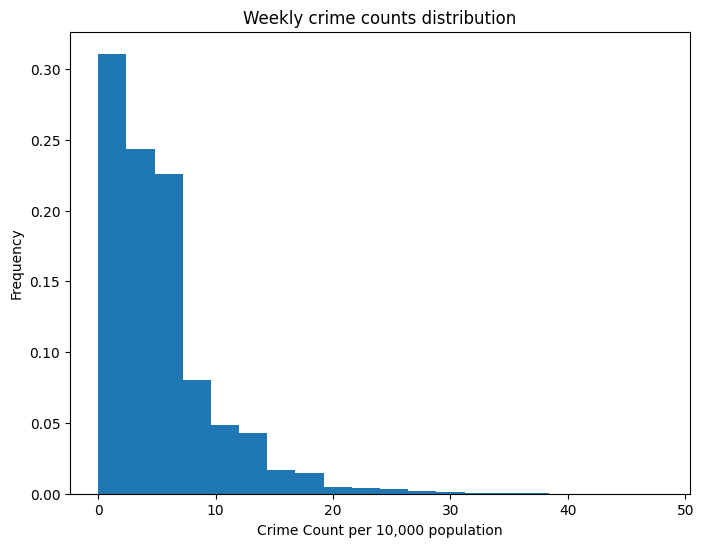

In [28]:
# Plot crime count histogram
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (8, 6)
num_bins = 20   # number of bins to create
plt.hist(df1['Crime_counts'], num_bins, weights=np.zeros_like(df1['Crime_counts']) + 1. / df1['Crime_counts'].size)
plt.title("Weekly crime counts distribution")
plt.xlabel("Crime Count per 10,000 population")
plt.ylabel("Frequency")

[Text(0, 0, '1.79'), Text(0, 0, '1.79'), Text(0, 0, '1.79')]

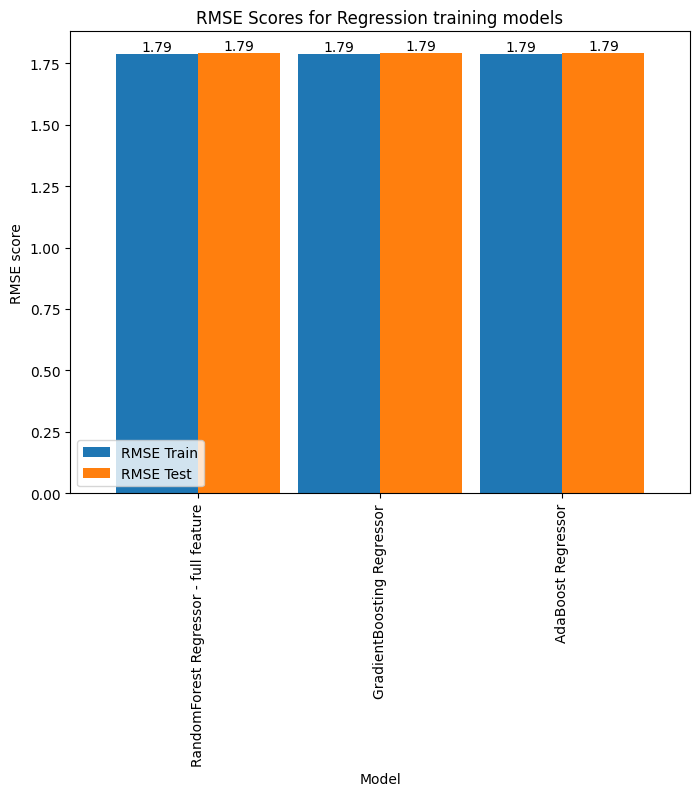

In [29]:
# Plot the histogram of RMSE for each model
bar_plot6 = rmse_scores.plot(x = 'Model',  y = ['RMSE Train','RMSE Test'], kind='bar', width=0.9)
plt.style.use('seaborn-v0_8-deep')
plt.rcParams["figure.figsize"] = (12, 6)
#plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, p: format(int(y), ',')))
plt.ylabel("RMSE score")
plt.title("RMSE Scores for Regression training models")
bar_plot6.bar_label(bar_plot6.containers[0], fmt='{:,.2f}')
bar_plot6.bar_label(bar_plot6.containers[1], fmt='{:,.2f}')
#plt.xticks(rotation=60)